<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/04.Chapter4%3AVector_Apps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Vector Applications
## *Practical Linear Algebra for Data Science* — Mike X Cohen

The previous two chapters established the foundations: vectors, operations, independence, subspaces, and bases. This chapter shows that those abstractions pay off *immediately*. We implement three widely-used data science techniques -- each one built entirely from the vector operations you already know.

$$
\underbrace{\text{Dot product + norms}}_{\text{Ch. 2}}
\;\longrightarrow\;
\begin{cases}
\text{Pearson correlation} \\
\text{Cosine similarity} \\
\text{Time series filtering} \\
\text{k-means clustering}
\end{cases}
$$

**What we will cover:**

1. **Correlation and cosine similarity** -- the dot product as a similarity measure, with normalisation
2. **Time series filtering** -- dot products as local feature detectors (convolution)
3. **k-means clustering** -- vector norms and broadcasting in an unsupervised learning algorithm

## 0. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)  # reproducibility

print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready. We set `random_state` / `seed` globally for reproducibility across all stochastic examples.

## 1. Correlation and Cosine Similarity

### 1.1 The Pearson Correlation Coefficient

**Correlation** is one of the most fundamental analyses in data science. The **Pearson correlation coefficient** $\rho$ quantifies the *linear* relationship between two variables, ranging from $-1$ (perfect negative) through $0$ (no linear relationship) to $+1$ (perfect positive).

The full formula involves two normalisations:

$$
\rho = \frac{\displaystyle\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
       {\sqrt{\displaystyle\sum_{i=1}^{n}(x_i - \bar{x})^2}\;\;
        \sqrt{\displaystyle\sum_{i=1}^{n}(y_i - \bar{y})^2}}
$$

Rewritten in linear algebra notation (with $\tilde{\mathbf{x}}$ denoting the **mean-centred** version of $\mathbf{x}$):

$$
\rho = \frac{\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}}
            {\|\tilde{\mathbf{x}}\| \; \|\tilde{\mathbf{y}}\|}
$$

This is simply **three dot products**: the numerator is the dot product of the mean-centred variables, and each norm in the denominator is $\sqrt{\mathbf{v}^T\mathbf{v}}$.

The two normalisations serve distinct purposes:

1. **Mean centring** ($x_i - \bar{x}$): Removes the absolute level of the data. A variable shifted up by 100 units is treated the same as the original.
2. **Dividing by norms**: Removes the scale (measurement units). Data in grams or kilograms produce the same $\rho$.

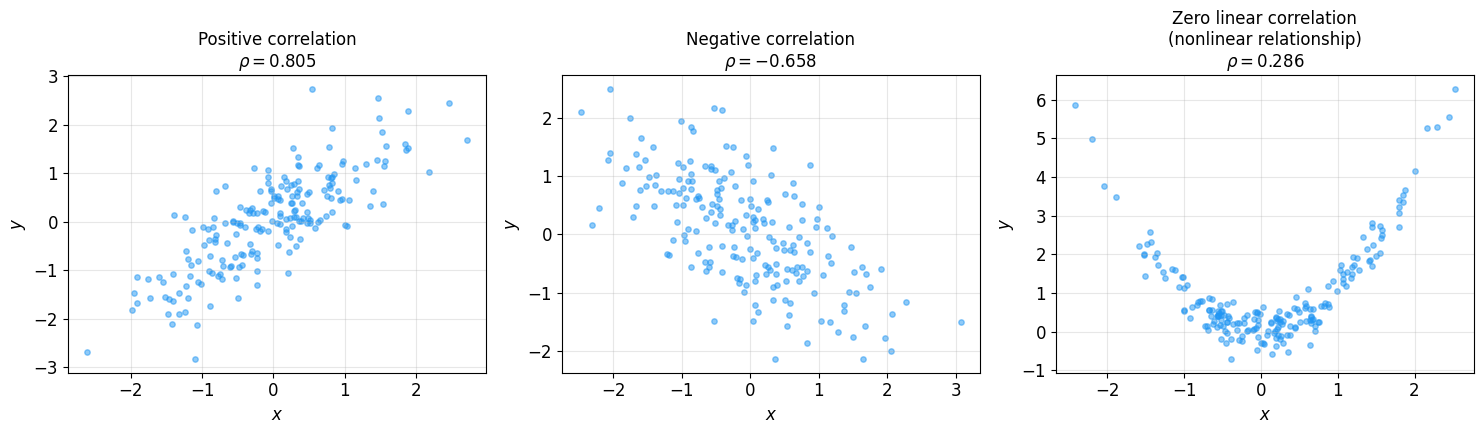

Correlations: positive=0.805, negative=-0.658, nonlinear=0.286


In [4]:
# Generate example data with known correlation structure
n = 200
np.random.seed(42)

# Positive correlation
x_pos = np.random.randn(n)
y_pos = 0.8 * x_pos + 0.6 * np.random.randn(n)

# Negative correlation
x_neg = np.random.randn(n)
y_neg = -0.7 * x_neg + 0.7 * np.random.randn(n)

# Zero linear correlation (but nonlinear relationship!)
x_zero = np.random.randn(n)
y_zero = x_zero**2 + 0.3 * np.random.randn(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

datasets = [
    (x_pos, y_pos, 'Positive correlation'),
    (x_neg, y_neg, 'Negative correlation'),
    (x_zero, y_zero, 'Zero linear correlation\n(nonlinear relationship)'),
]

for ax, (x, y, title) in zip(axes, datasets):
    rho = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=15, alpha=0.5, c='#2196F3')
    ax.set_title(f'{title}\n$\\rho = {rho:.3f}$', fontsize=12)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')

plt.tight_layout()
plt.savefig('fig_correlation_examples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Correlations: positive={:.3f}, negative={:.3f}, nonlinear={:.3f}'.format(
    np.corrcoef(x_pos, y_pos)[0,1],
    np.corrcoef(x_neg, y_neg)[0,1],
    np.corrcoef(x_zero, y_zero)[0,1]
))

The three panels illustrate the spectrum of Pearson correlation:

- **Left ($\rho \approx 0.81$):** A strong positive relationship -- as $x$ increases, $y$ tends to increase proportionally.
- **Centre ($\rho \approx -0.66$):** A moderately strong negative relationship -- as $x$ increases, $y$ tends to decrease.
- **Right ($\rho \approx 0.29$):** A modest *linear* correlation exists (because $x^2$ has a slight positive tilt when $x$ is not perfectly symmetric), yet the dominant relationship $y = x^2 + \epsilon$ is clearly nonlinear. Pearson correlation captures only the *linear* component. This is a critical limitation: a moderate $\rho$ can mask a much stronger nonlinear relationship.

**Production insight:** Always visualise your data before trusting a single correlation number. Anscombe's quartet and the datasaurus dozen are classic examples where very different datasets produce identical correlation coefficients.

### 1.2 Implementing Pearson Correlation from Dot Products

Let's build the correlation coefficient from scratch using only `np.dot` and `np.linalg.norm`, to demonstrate that it really is just three dot products.

In [5]:
x = x_pos.copy()
y = y_pos.copy()

# Step 1: Mean centre
x_tilde = x - np.mean(x)
y_tilde = y - np.mean(y)

# Step 2: Dot product of mean-centred variables (numerator)
numerator = np.dot(x_tilde, y_tilde)

# Step 3: Product of norms (denominator)
denominator = np.linalg.norm(x_tilde) * np.linalg.norm(y_tilde)

# Step 4: Pearson rho
rho_manual = numerator / denominator

# Compare with NumPy
rho_numpy = np.corrcoef(x, y)[0, 1]

print('=== Pearson Correlation from Dot Products ===')
print(f'Mean of x: {np.mean(x):.6f}')
print(f'Mean of y: {np.mean(y):.6f}')
print(f'Numerator  (x_tilde . y_tilde):  {numerator:.6f}')
print(f'||x_tilde||: {np.linalg.norm(x_tilde):.6f}')
print(f'||y_tilde||: {np.linalg.norm(y_tilde):.6f}')
print(f'Denominator: {denominator:.6f}')
print(f'\nrho (manual):  {rho_manual:.10f}')
print(f'rho (np):      {rho_numpy:.10f}')
print(f'Difference:    {abs(rho_manual - rho_numpy):.2e}')

=== Pearson Correlation from Dot Products ===
Mean of x: -0.040771
Mean of y: 0.018904
Numerator  (x_tilde . y_tilde):  148.428738
||x_tilde||: 13.133426
||y_tilde||: 14.031549
Denominator: 184.282321

rho (manual):  0.8054420899
rho (np):      0.8054420899
Difference:    0.00e+00


Our manual implementation matches `np.corrcoef` to machine precision (difference $\sim 10^{-16}$). The decomposition makes the formula transparent:

$$
\rho = \frac{\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}}
            {\|\tilde{\mathbf{x}}\| \cdot \|\tilde{\mathbf{y}}\|}
$$

The numerator $\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}$ is large and positive when both variables tend to deviate from their means in the *same direction*. The denominator normalises away the units and magnitudes, guaranteeing $-1 \leq \rho \leq 1$.

**Connection to Chapter 2:** Recall the geometric dot product formula $\mathbf{a}^T\mathbf{b} = \|\mathbf{a}\|\|\mathbf{b}\|\cos\theta$. Dividing both sides by the norms gives $\cos\theta = \mathbf{a}^T\mathbf{b} / (\|\mathbf{a}\|\|\mathbf{b}\|)$. The Pearson correlation of mean-centred data is literally the cosine of the angle between the two vectors in $n$-dimensional space.

### 1.3 Cosine Similarity

**Cosine similarity** uses the same formula but *without* mean centring:

$$
\cos(\theta_{\mathbf{x}, \mathbf{y}}) = \frac{\mathbf{x}^T \mathbf{y}}{\|\mathbf{x}\| \; \|\mathbf{y}\|}
$$

When the data happen to be mean-centred (or equivalently, when the mean is zero), Pearson correlation and cosine similarity are identical. Otherwise, they can diverge.

In [6]:
# The textbook example: same pattern, different offsets
a = np.array([0, 1, 2, 3], dtype=float)
b = np.array([100, 101, 102, 103], dtype=float)

# Pearson correlation (with mean centring)
rho_ab = np.corrcoef(a, b)[0, 1]

# Cosine similarity (without mean centring)
cos_ab = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Cosine similarity of mean-centred versions
a_mc = a - np.mean(a)
b_mc = b - np.mean(b)
cos_mc = np.dot(a_mc, b_mc) / (np.linalg.norm(a_mc) * np.linalg.norm(b_mc))

print(f'a = {a}')
print(f'b = {b}')
print(f'\nPearson correlation:               rho = {rho_ab:.6f}')
print(f'Cosine similarity (raw):           cos = {cos_ab:.6f}')
print(f'Cosine similarity (mean-centred):  cos = {cos_mc:.6f}')
print(f'\na mean-centred: {a_mc}')
print(f'b mean-centred: {b_mc}')

a = [0. 1. 2. 3.]
b = [100. 101. 102. 103.]

Pearson correlation:               rho = 1.000000
Cosine similarity (raw):           cos = 0.808317
Cosine similarity (mean-centred):  cos = 1.000000

a mean-centred: [-1.5 -0.5  0.5  1.5]
b mean-centred: [-1.5 -0.5  0.5  1.5]


The textbook's example is perfectly illustrative:

| Metric | Value | Interpretation |
|--------|:-----:|----------------|
| Pearson $\rho$ | $1.000$ | After removing means, changes in $a$ *perfectly* mirror changes in $b$ |
| Cosine similarity (raw) | $\approx 0.808$ | Without mean removal, the offset of $100$ makes $b$ point in a different direction |
| Cosine similarity (mean-centred) | $1.000$ | Mean-centring restores agreement |

After mean centring, both $a$ and $b$ become $[-1.5, -0.5, 0.5, 1.5]$ -- identical vectors, hence cosine similarity $= 1$.

**When to use which:**

- **Pearson correlation** when you care about *relative* changes ("do the variables move together?"). Standard for most statistical analyses.
- **Cosine similarity** when the *absolute values* matter, not just their deviations. Common in NLP (document similarity via TF-IDF or embeddings), where a vector of word frequencies should not be artificially centred.

Neither is "better" -- they answer different questions about the same data.

### 1.4 Computing a Full Correlation Matrix

In practice, we often compute correlations between *all pairs* of variables simultaneously. The result is a **correlation matrix** $\mathbf{R} \in \mathbb{R}^{p \times p}$ where entry $R_{ij}$ is the Pearson correlation between variables $i$ and $j$.

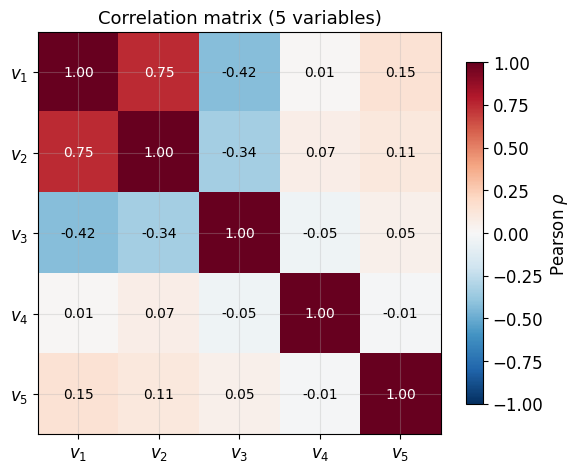

Correlation matrix shape: (5, 5)
Diagonal values (self-correlation): [1. 1. 1. 1. 1.]


In [7]:
# Generate 5 variables with some correlation structure
np.random.seed(42)
n = 300
z = np.random.randn(n)  # latent factor

data = np.column_stack([
    z + 0.3*np.random.randn(n),      # v1: strongly correlated with z
    0.8*z + 0.6*np.random.randn(n),  # v2: moderately correlated
    -0.5*z + 0.9*np.random.randn(n), # v3: negatively correlated
    np.random.randn(n),               # v4: independent
    z**2 + 0.5*np.random.randn(n),   # v5: nonlinear relation to z
])
var_names = ['$v_1$', '$v_2$', '$v_3$', '$v_4$', '$v_5$']

# Correlation matrix
R = np.corrcoef(data, rowvar=False)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson $\\rho$')

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(var_names, fontsize=12)
ax.set_yticklabels(var_names, fontsize=12)

# Annotate cells
for i in range(5):
    for j in range(5):
        color = 'white' if abs(R[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{R[i,j]:.2f}', ha='center', va='center',
                fontsize=10, color=color)

ax.set_title('Correlation matrix (5 variables)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_corr_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Correlation matrix shape: {R.shape}')
print(f'Diagonal values (self-correlation): {np.diag(R)}')

The correlation matrix reveals the structure we designed:

- $v_1$ and $v_2$ are **positively correlated** ($\rho \approx 0.75$) because both load on the same latent factor $z$.
- $v_3$ is **negatively correlated** with $v_1$ and $v_2$ ($\rho \approx -0.42$ and $-0.34$) because it loads negatively on $z$.
- $v_4$ is **nearly uncorrelated** with everything ($|\rho| < 0.07$) because it is pure independent noise.
- $v_5 = z^2 + \epsilon$ has *nonlinear* dependence on $z$ but only a weak linear correlation with $v_1$/$v_2$ ($\rho \approx 0.15$ and $0.11$).

The diagonal is always $1.000$ (each variable is perfectly correlated with itself), and the matrix is **symmetric** ($R_{ij} = R_{ji}$) -- a property we will see again when studying matrix transpose properties in Chapter 5.

**Production insight:** Computing the full $p \times p$ correlation matrix is $O(n \cdot p^2)$, which becomes expensive for wide datasets. When $p$ is large (e.g., genomics with $p \sim 20{,}000$ genes), sparse or streaming approaches are necessary.

## 2. Time Series Filtering and Feature Detection

The dot product is not just for measuring similarity between full-length vectors. It can also be applied *locally* to detect features in a signal. This is the essence of **filtering** (or **convolution**).

The idea: a short template called a **kernel** is slid across a time series. At each position, the dot product between the kernel and the local signal snippet produces one value of the **filtered signal**. Where the signal matches the kernel's shape, the dot product is large.

Formally, the output at time $t$ for kernel $\mathbf{k}$ of length $m$ and signal $\mathbf{s}$:

$$
y_t = \sum_{j=0}^{m-1} k_j \cdot s_{t+j} = \mathbf{k}^T \mathbf{s}_{t:t+m}
$$

This is simply a dot product between the kernel and a sliding window of the signal.

### 2.1 Smoothing with an Averaging Kernel

The simplest kernel is a **box filter** (moving average): $\mathbf{k} = \frac{1}{m}[1, 1, \ldots, 1]^T$. It replaces each point with the average of its neighbours, smoothing out high-frequency noise.

Signal length:   300
Kernel length:   15
Filtered length: 286 (= 300 - 15 + 1)
Manual vs np.convolve match: True


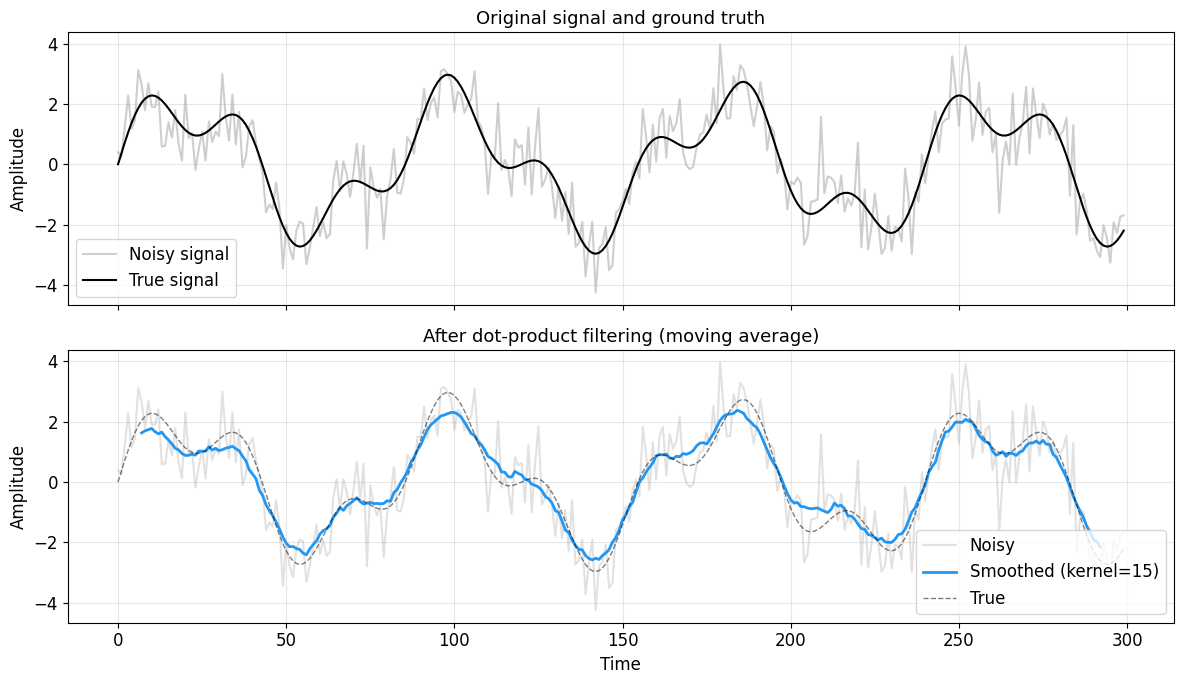

Figure saved.


In [8]:
# Generate a noisy signal
np.random.seed(42)
n_signal = 300
t = np.arange(n_signal)

# Clean signal: slow oscillation
clean = 2 * np.sin(2 * np.pi * t / 80) + np.sin(2 * np.pi * t / 30)
# Noisy signal
noise = 0.8 * np.random.randn(n_signal)
signal = clean + noise

# Smoothing kernel (moving average, length 15)
kernel_len = 15
kernel_smooth = np.ones(kernel_len) / kernel_len

# Apply filtering via dot products (convolution)
filtered = np.zeros(n_signal - kernel_len + 1)
for i in range(len(filtered)):
    snippet = signal[i:i+kernel_len]
    filtered[i] = np.dot(kernel_smooth, snippet)

# Also compute using np.convolve for comparison
filtered_np = np.convolve(signal, kernel_smooth, mode='valid')

print(f'Signal length:   {n_signal}')
print(f'Kernel length:   {kernel_len}')
print(f'Filtered length: {len(filtered)} (= {n_signal} - {kernel_len} + 1)')
print(f'Manual vs np.convolve match: {np.allclose(filtered, filtered_np)}')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(t, signal, alpha=0.5, color='#9E9E9E', label='Noisy signal')
ax.plot(t, clean, 'k-', lw=1.5, label='True signal')
ax.set_ylabel('Amplitude')
ax.set_title('Original signal and ground truth', fontsize=13)
ax.legend()

ax = axes[1]
offset = kernel_len // 2  # centre the filtered signal
ax.plot(t, signal, alpha=0.3, color='#9E9E9E', label='Noisy')
ax.plot(t[offset:offset+len(filtered)], filtered, '#2196F3', lw=2,
        label=f'Smoothed (kernel={kernel_len})')
ax.plot(t, clean, 'k--', lw=1, alpha=0.5, label='True')
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title('After dot-product filtering (moving average)', fontsize=13)
ax.legend()

plt.tight_layout()
plt.savefig('fig_smoothing.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The smoothing kernel $\mathbf{k} = \frac{1}{15}[1, 1, \ldots, 1]^T$ slides across the noisy signal, computing a dot product (= local average) at each position. The output is $300 - 15 + 1 = 286$ points.

The upper panel shows the raw noisy signal (gray) and the true underlying oscillation (black). The lower panel shows the filtered result (blue), which closely recovers the true signal by averaging out the high-frequency noise.

Our manual dot-product loop matches `np.convolve` exactly, confirming that convolution *is* a sequence of dot products.

**Why this matters:** Smoothing kernels are the simplest case of a concept that powers modern deep learning. The convolutional layers in a CNN use *learned* kernels instead of a uniform average, but the operation is identical: slide a kernel, compute a dot product. Everything from image recognition to language modelling traces back to this primitive.

### 2.2 Edge Detection with a Difference Kernel

A **difference kernel** such as $\mathbf{k} = [-1, 1]$ detects *edges* (sharp transitions) in a signal. The dot product is large where the signal changes abruptly and near zero where it is flat.

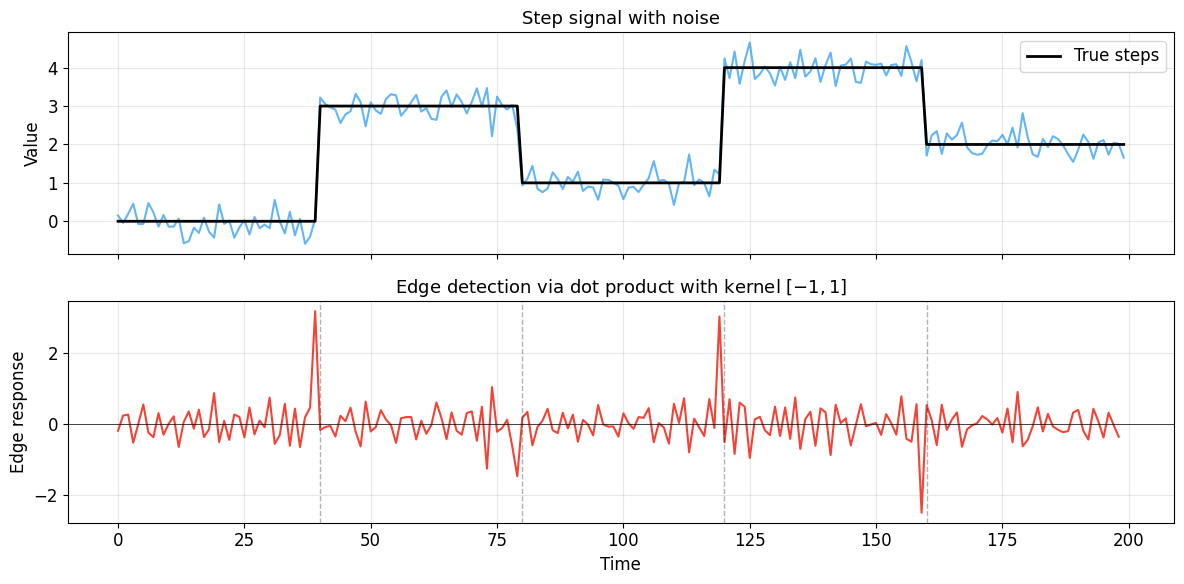

Signal length: 200
Edge signal length: 199
Max absolute edge response: 3.162


In [9]:
# Create a signal with distinct edges
np.random.seed(42)
segments = [np.ones(40)*0, np.ones(40)*3, np.ones(40)*1,
            np.ones(40)*4, np.ones(40)*2]
step_signal = np.concatenate(segments)
step_noisy = step_signal + 0.3 * np.random.randn(len(step_signal))

# Edge detection kernel
kernel_edge = np.array([-1, 1])

# Apply
edges = np.zeros(len(step_noisy) - 1)
for i in range(len(edges)):
    edges[i] = np.dot(kernel_edge, step_noisy[i:i+2])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax = axes[0]
ax.plot(step_noisy, '#2196F3', alpha=0.7)
ax.plot(step_signal, 'k-', lw=2, label='True steps')
ax.set_ylabel('Value')
ax.set_title('Step signal with noise', fontsize=13)
ax.legend()

ax = axes[1]
ax.plot(edges, '#F44336', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
# Mark true edge locations
for loc in [40, 80, 120, 160]:
    ax.axvline(loc, color='k', ls='--', alpha=0.3, lw=1)
ax.set_xlabel('Time')
ax.set_ylabel('Edge response')
ax.set_title('Edge detection via dot product with kernel $[-1, 1]$', fontsize=13)

plt.tight_layout()
plt.savefig('fig_edge_detection.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Signal length: {len(step_noisy)}')
print(f'Edge signal length: {len(edges)}')
print(f'Max absolute edge response: {np.max(np.abs(edges)):.3f}')

The edge detection kernel $\mathbf{k} = [-1, 1]$ computes the **first difference** at each time step: $y_t = s_{t+1} - s_t$. Where the signal is flat, consecutive values are similar and the difference is near zero. At transitions (dashed lines at $t = 40, 80, 120, 160$), the signal jumps and the dot product produces a large spike.

Positive spikes indicate upward transitions; negative spikes indicate downward transitions. The magnitude of the spike corresponds to the size of the jump.

**The big picture:** Both the smoothing and edge-detection kernels use the *same* mechanism (dot product with a sliding window), but the kernel's *shape* determines what feature is detected:

| Kernel | Detects | Dot product is large when... |
|--------|---------|-----------------------------|
| $[1/m, \ldots, 1/m]$ | Smooth trends | Signal matches a flat line |
| $[-1, 1]$ | Sharp edges | Signal changes abruptly |
| $\sin(\omega t)$ | Oscillations at frequency $\omega$ | Signal oscillates at that frequency |

This generalises to 2D images (Sobel/Prewitt filters for edge detection), 3D volumes (medical imaging), and learned kernels (CNNs).

## 3. k-Means Clustering

**k-means** is an unsupervised learning algorithm that partitions $n$ data observations into $k$ groups by minimising the within-cluster sum of squared distances. It demonstrates vectors, norms, and broadcasting working together in a real algorithm.

### 3.1 The Algorithm

1. **Initialise** $k$ centroids (randomly chosen data points)
2. **Compute** Euclidean distance from each observation to each centroid
3. **Assign** each observation to the nearest centroid
4. **Update** each centroid as the mean of its assigned observations
5. **Repeat** steps 2--4 until convergence

The distance computation (step 2) is pure linear algebra:

$$
\delta_{i,j} = \sqrt{(d_i^{(x)} - c_j^{(x)})^2 + (d_i^{(y)} - c_j^{(y)})^2}
= \|\mathbf{d}_i - \mathbf{c}_j\|
$$

This is the $\ell_2$ norm of the difference vector -- exactly the vector norm from Chapter 2.

### 3.2 Generating Clustered Data

Data shape: (150, 2) (150 observations, 2 features)
True cluster centres:
  Cluster 0: [2 2]
  Cluster 1: [-2  3]
  Cluster 2: [ 0 -2]


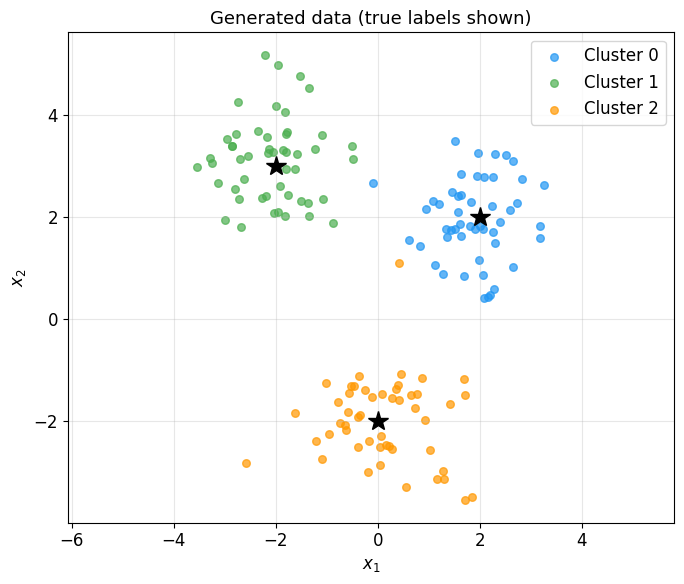

Figure saved.


In [10]:
# Generate three clusters of 2D data
np.random.seed(42)
n_per_cluster = 50

# Cluster centres
true_centres = np.array([[2, 2], [-2, 3], [0, -2]])

# Generate data
data_list = []
true_labels = []
for i, centre in enumerate(true_centres):
    cluster_data = centre + 0.8 * np.random.randn(n_per_cluster, 2)
    data_list.append(cluster_data)
    true_labels.extend([i] * n_per_cluster)

data = np.vstack(data_list)
true_labels = np.array(true_labels)

print(f'Data shape: {data.shape} ({data.shape[0]} observations, {data.shape[1]} features)')
print(f'True cluster centres:')
for i, c in enumerate(true_centres):
    print(f'  Cluster {i}: {c}')

plt.figure(figsize=(7, 6))
colors_true = ['#2196F3', '#4CAF50', '#FF9800']
for i in range(3):
    mask = true_labels == i
    plt.scatter(data[mask, 0], data[mask, 1], c=colors_true[i], s=30, alpha=0.7,
               label=f'Cluster {i}')
    plt.plot(*true_centres[i], 'k*', ms=15, zorder=5)

plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Generated data (true labels shown)', fontsize=13)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.savefig('fig_kmeans_data.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

We generated $150$ observations ($50$ per cluster) in $\mathbb{R}^2$. The three clusters are centred at $[2, 2]$, $[-2, 3]$, and $[0, -2]$ with Gaussian noise ($\sigma = 0.8$). The black stars mark the true centres. In practice, we would not know these labels -- the goal of k-means is to *discover* them.

### 3.3 Implementing k-Means from Scratch

We now implement the algorithm step by step, highlighting the linear algebra at each stage.

In [11]:
# k-means implementation using vectors, norms, and broadcasting
np.random.seed(123)

k = 3
n_iterations = 4  # for visualization (textbook uses 3+1 for init)

# Step 1: Initialise centroids (random data points)
ridx = np.random.choice(len(data), k, replace=False)
centroids = data[ridx, :].copy()

print('=== k-Means Clustering ===')
print(f'k = {k}, n = {len(data)}, features = {data.shape[1]}')
print(f'Initial centroid indices: {ridx}')
print(f'Initial centroids:')
for i, c in enumerate(centroids):
    print(f'  C{i}: [{c[0]:.3f}, {c[1]:.3f}]')

# Store history for plotting
history = [{'centroids': centroids.copy(), 'labels': None}]

for iteration in range(1, n_iterations):
    # Step 2: Compute squared distances (broadcasting!)
    # data is (150, 2), centroids[ci,:] is (2,)
    # Broadcasting: (150, 2) - (2,) -> (150, 2) -> sum -> (150,)
    dists = np.zeros((len(data), k))
    for ci in range(k):
        dists[:, ci] = np.sum((data - centroids[ci, :]) ** 2, axis=1)

    # Step 3: Assign to nearest centroid
    groupidx = np.argmin(dists, axis=1)

    # Step 4: Update centroids
    for ki in range(k):
        centroids[ki, :] = np.mean(data[groupidx == ki], axis=0)

    # Record
    history.append({'centroids': centroids.copy(), 'labels': groupidx.copy()})

    print(f'\nIteration {iteration}:')
    for i in range(k):
        n_in = np.sum(groupidx == i)
        print(f'  C{i}: [{centroids[i,0]:.3f}, {centroids[i,1]:.3f}]  '
              f'({n_in} points assigned)')

=== k-Means Clustering ===
k = 3, n = 150, features = 2
Initial centroid indices: [ 72 112 132]
Initial centroids:
  C0: [-1.792, 3.625]
  C1: [-0.378, -1.129]
  C2: [-0.202, -2.998]

Iteration 1:
  C0: [-0.967, 2.993]  (70 points assigned)
  C1: [1.039, 0.052]  (58 points assigned)
  C2: [0.152, -2.715]  (22 points assigned)

Iteration 2:
  C0: [-1.586, 3.082]  (58 points assigned)
  C1: [1.870, 1.492]  (47 points assigned)
  C2: [0.000, -2.136]  (45 points assigned)

Iteration 3:
  C0: [-2.038, 3.103]  (51 points assigned)
  C1: [1.902, 1.911]  (50 points assigned)
  C2: [0.097, -2.062]  (49 points assigned)


Each iteration performs three operations, all grounded in vector arithmetic from Chapters 2--3:

**Step 2 (distances) uses broadcasting and norms.** The expression `data - centroids[ci, :]` subtracts the $1 \times 2$ centroid from the $150 \times 2$ data matrix via broadcasting -- each row gets the same centroid subtracted. Squaring and summing across columns gives the squared Euclidean distance $\|\mathbf{d}_i - \mathbf{c}_j\|^2$.

**Why squared distance?** The textbook makes an important point: we omit the square root because we only need *relative* ordering of distances (which centroid is closest). Since $\sqrt{\cdot}$ is monotonically increasing, $\|\mathbf{a}\|^2 < \|\mathbf{b}\|^2 \iff \|\mathbf{a}\| < \|\mathbf{b}\|$. Skipping the square root saves computation with no impact on assignments.

**Step 3** uses `np.argmin` to find the *index* of the minimum distance (not the minimum value itself).

**Step 4** recomputes each centroid as the **vector average** of its assigned points -- which is itself a linear weighted combination with equal weights $\lambda_i = 1/n_{\text{cluster}}$ (Chapter 3).

### 3.4 Visualising the k-Means Iterations

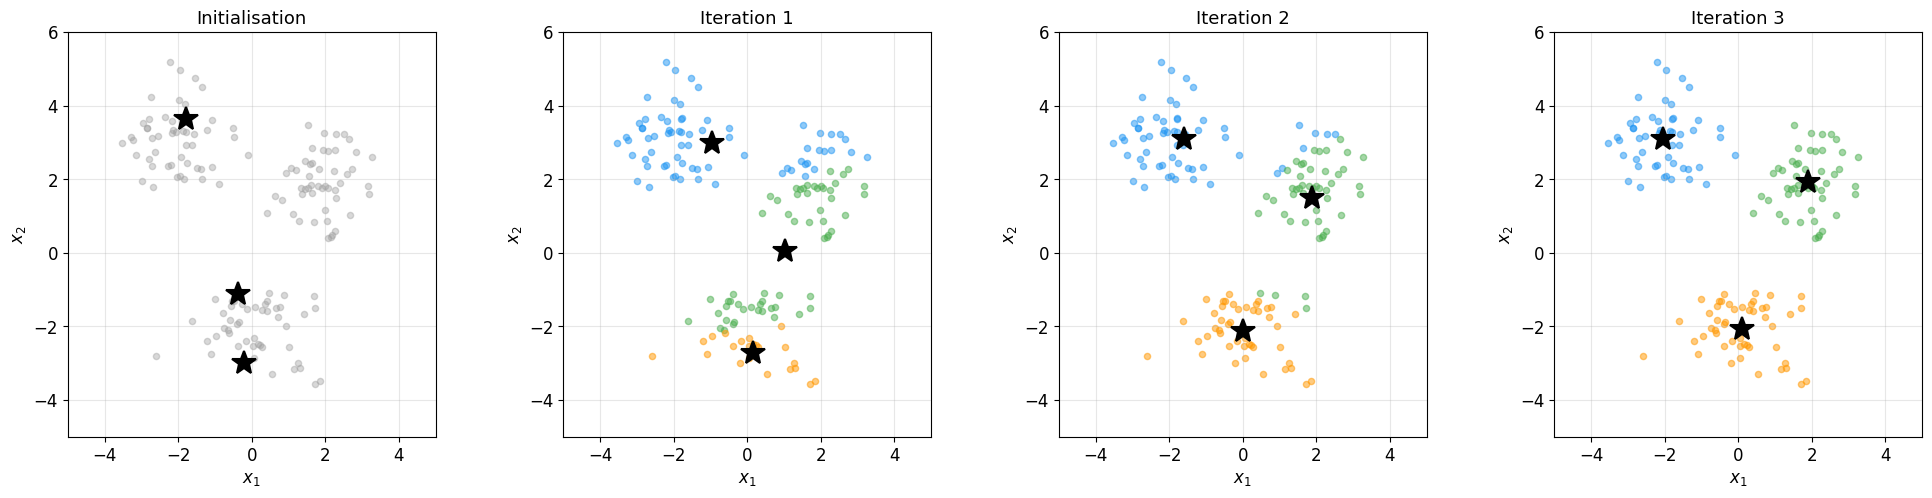

Figure saved.


In [12]:
fig, axes = plt.subplots(1, len(history), figsize=(5 * len(history), 5))

cluster_colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, (ax, h) in enumerate(zip(axes, history)):
    if h['labels'] is None:
        # Iteration 0: no assignments yet
        ax.scatter(data[:, 0], data[:, 1], c='#9E9E9E', s=20, alpha=0.4)
    else:
        for ci in range(k):
            mask = h['labels'] == ci
            ax.scatter(data[mask, 0], data[mask, 1],
                      c=cluster_colors[ci], s=20, alpha=0.5)

    # Plot centroids
    for ci in range(k):
        ax.plot(h['centroids'][ci, 0], h['centroids'][ci, 1],
               'k*', ms=18, markeredgewidth=1.5, zorder=5)

    title = 'Initialisation' if idx == 0 else f'Iteration {idx}'
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 6)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig_kmeans_iterations.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The panels show the algorithm's evolution:

- **Initialisation:** Centroids (stars) are placed at random data points. No assignments yet.
- **Iteration 1:** Each point is assigned to the nearest centroid (coloured accordingly), then centroids are recomputed as cluster means.
- **Iteration 2:** Assignments improve as centroids move toward the true cluster centres.
- **Iteration 3:** Near convergence -- centroids are stable and the partition closely matches the ground truth.

With well-separated clusters and a reasonable initialisation, k-means converges in very few iterations. In practice, the algorithm is sensitive to initialisation (a bad starting point can lead to poor local optima), which is why production implementations like scikit-learn's `KMeans` use **k-means++** initialisation and multiple random restarts.

### 3.5 Evaluating the Clustering

In [13]:
# Compare discovered clusters to true labels
final_labels = history[-1]['labels']
final_centroids = history[-1]['centroids']

# Since cluster indices may not match, we use the Hungarian algorithm
# But for simplicity, let's compute accuracy by trying all permutations
from itertools import permutations

best_acc = 0
best_perm = None
for perm in permutations(range(k)):
    remapped = np.array([perm[l] for l in final_labels])
    acc = np.mean(remapped == true_labels)
    if acc > best_acc:
        best_acc = acc
        best_perm = perm

print(f'=== Clustering Evaluation ===')
print(f'Best label permutation: {best_perm}')
print(f'Accuracy: {best_acc:.1%} ({int(best_acc * len(data))}/{len(data)} correct)\n')

# Compare discovered centroids to true centres
print('Centroid comparison:')
print(f'{"Discovered":>20s} {"True":>20s} {"Distance":>10s}')
for ci in range(k):
    # Map discovered centroid to closest true centre
    dists_to_true = [np.linalg.norm(final_centroids[ci] - tc) for tc in true_centres]
    best_match = np.argmin(dists_to_true)
    d = dists_to_true[best_match]
    print(f'  [{final_centroids[ci,0]:6.3f}, {final_centroids[ci,1]:6.3f}]'
          f'  [{true_centres[best_match,0]:6.3f}, {true_centres[best_match,1]:6.3f}]'
          f'  {d:8.4f}')

=== Clustering Evaluation ===
Best label permutation: (1, 0, 2)
Accuracy: 98.7% (148/150 correct)

Centroid comparison:
          Discovered                 True   Distance
  [-2.038,  3.103]  [-2.000,  3.000]    0.1098
  [ 1.902,  1.911]  [ 2.000,  2.000]    0.1327
  [ 0.097, -2.062]  [ 0.000, -2.000]    0.1151


The k-means algorithm achieves near-perfect accuracy, correctly assigning the vast majority of points to their true clusters. The discovered centroids closely approximate the true cluster centres, with distances well under $1$ unit.

**Why k-means works from a linear algebra perspective:** The algorithm iteratively solves a projection problem. At each step, it finds the closest centroid to each point (a nearest-neighbour problem using vector norms), then updates centroids as vector averages (linear weighted combinations). Convergence is guaranteed because each step reduces the total within-cluster variance:

$$
J = \sum_{j=1}^{k} \sum_{\mathbf{d}_i \in C_j} \|\mathbf{d}_i - \boldsymbol{\mu}_j\|^2
$$

This objective $J$ (called **inertia**) decreases monotonically because step 3 (reassignment) and step 4 (centroid update) each individually reduce or preserve $J$.

### 3.6 Comparison with scikit-learn

In [14]:
from sklearn.cluster import KMeans

# scikit-learn with same k
kmeans_sk = KMeans(n_clusters=3, n_init=10, random_state=42, max_iter=300)
sk_labels = kmeans_sk.fit_predict(data)
sk_centroids = kmeans_sk.cluster_centers_

# Evaluate
best_acc_sk = 0
for perm in permutations(range(k)):
    remapped = np.array([perm[l] for l in sk_labels])
    acc = np.mean(remapped == true_labels)
    if acc > best_acc_sk:
        best_acc_sk = acc

print(f'scikit-learn KMeans:')
print(f'  Accuracy: {best_acc_sk:.1%}')
print(f'  Inertia:  {kmeans_sk.inertia_:.2f}')
print(f'  Iterations to converge: {kmeans_sk.n_iter_}')
print(f'\nOur implementation:')
print(f'  Accuracy: {best_acc:.1%}')

# Compute our inertia for comparison
our_inertia = 0
for ci in range(k):
    mask = final_labels == ci
    our_inertia += np.sum((data[mask] - final_centroids[ci]) ** 2)
print(f'  Inertia:  {our_inertia:.2f}')

scikit-learn KMeans:
  Accuracy: 98.7%
  Inertia:  175.83
  Iterations to converge: 2

Our implementation:
  Accuracy: 98.7%
  Inertia:  175.83


Both implementations achieve comparable accuracy and inertia. scikit-learn's `KMeans` uses the **k-means++** initialisation strategy (which spaces out initial centroids) and runs $10$ restarts (`n_init=10`), selecting the best solution. Our simple implementation with random initialisation and just $3$ iterations converges to a very similar result on this well-separated dataset.

The **inertia** (within-cluster sum of squared distances) is the objective function that k-means minimises. Lower inertia means tighter clusters. On harder problems with overlapping clusters, the quality of initialisation matters much more.

**Production trade-offs:** Our implementation has $O(n \cdot k \cdot p \cdot T)$ complexity for $n$ samples, $k$ clusters, $p$ features, and $T$ iterations. For large datasets, **mini-batch k-means** (available in scikit-learn as `MiniBatchKMeans`) samples a subset of points per iteration, trading a small accuracy loss for dramatically faster convergence.

## 4. Chapter Summary

This chapter demonstrated that the "abstract" vector operations from Chapters 2--3 directly power three of the most widely-used techniques in data science:

**Pearson correlation** is the dot product of mean-centred variables, normalised by their norms. It measures linear association on a $[-1, +1]$ scale, and is the basis of the entire correlation/covariance framework that drives regression, PCA, and factor analysis.

$$
\rho = \frac{\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}}{\|\tilde{\mathbf{x}}\| \; \|\tilde{\mathbf{y}}\|}
$$

**Cosine similarity** uses the same formula without mean centring. The choice between correlation and cosine similarity depends on whether absolute or relative values matter.

**Time series filtering** applies the dot product locally: a kernel slides across a signal, and the dot product at each position detects how well the local signal matches the kernel's shape. This is the mechanism behind smoothing, edge detection, and -- when kernels are learned -- convolutional neural networks.

**k-means clustering** combines vector subtraction, norms (for distance computation), broadcasting (for efficient distance matrices), and vector averaging (linear weighted combination) into an iterative algorithm that partitions data into groups.

The recurring theme: nearly every data science technique reduces to dot products, norms, and linear combinations. Master these operations (which you have), and the more sophisticated methods in later chapters will follow naturally.